In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import matplotlib 
matplotlib.rc('font', family='serif')
matplotlib.rc('font', serif='STIXGeneral')
from cmcrameri import cm  #cmap=cm.lipari 

from optical_setup import OpticalSetup
from CAM.vimbPy.controller import VimbaXController
from time import sleep

In [ ]:
opt_setup = OpticalSetup()

In [ ]:
opt_setup._dmd_on()

In [ ]:
print(opt_setup.dmd.h)
print(opt_setup.dmd.w)


matrix_height = int(opt_setup.dmd.h)
matrix_width = int(opt_setup.dmd.w)

Create Two Dots

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# Object matrix
Obj = np.zeros((matrix_height, matrix_width))

centre_x = matrix_width // 2
centre_y = matrix_height // 2
seperation = 700

# Circle settings
radius = 150

# Circle centres
x1 = centre_x - seperation // 2
x2 = centre_x + seperation // 2
y1 = y2 = centre_y

# Coordinate grids
Y, X = np.ogrid[:matrix_height, :matrix_width]

# Create filled circles
mask1 = (X - x1)**2 + (Y - y1)**2 <= radius**2
mask2 = (X - x2)**2 + (Y - y2)**2 <= radius**2

# Set circle pixels
Obj[mask1] = 255
Obj[mask2] = 255

# Convert to uint8
Obj = Obj.astype(np.uint8)

# Display
plt.imshow(Obj, origin='lower')
plt.title("Object: Two Filled Circles")
plt.show()

Send To DMD

In [ ]:
Obj=Obj[np.newaxis, np.newaxis, :, :]  # Add batch and channel dimensions
opt_setup._dmd_display(pattern=Obj , continuous=False)

In [ ]:
opt_setup._dmd_off()

In [ ]:
'''mask = np.ones(shape=(1, 1, opt_setup.dmd.h, opt_setup.dmd.w), dtype=np.uint8) * 255
mask[:, :, :, :opt_setup.dmd.w//5] = 0

plt.imshow(mask.squeeze())'''

In [ ]:
'''while True:
    opt_setup._dmd_display(pattern=mask, continuous=False)
    mask = np.roll(mask, shift=512, axis=-1)
    sleep(1/60)'''

Camera 

2026-06-01 14:17:54,449 - vimbPy_DEV_000F314CD29C - INFO - Cam DEV_000F314CD29C - Packet size adjusted successfully.
2026-06-01 14:17:54,449 - vimbPy_DEV_000F314CD29C - INFO - Cam DEV_000F314CD29C - Record started.


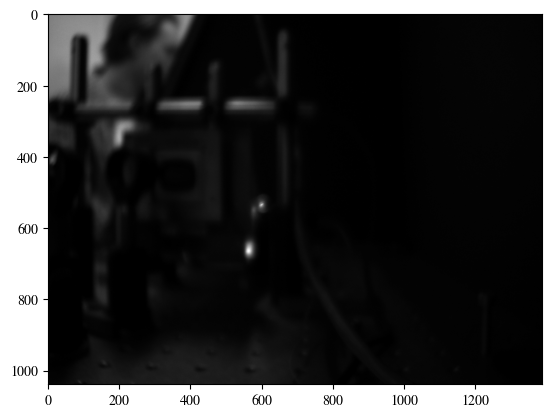

In [7]:

opt_setup._cams_on()

opt_setup.trigger_camera()

frame = opt_setup.q_single.get()

img = frame[1]

plt.imshow(img.squeeze(), cmap='gray')
plt.show()



In [ ]:
opt_setup._cams_off()